In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Ready to go!")

Ready to go!


In [3]:
df = pd.read_csv('data/2019.csv')

pd.set_option('display.max_columns', None)

print(df.shape)
print()
print(df.head())
print()
print(df.info)
print()
print(df.describe())


(156, 9)

   Overall rank Country or region  Score  GDP per capita  Social support  \
0             1           Finland  7.769           1.340           1.587   
1             2           Denmark  7.600           1.383           1.573   
2             3            Norway  7.554           1.488           1.582   
3             4           Iceland  7.494           1.380           1.624   
4             5       Netherlands  7.488           1.396           1.522   

   Healthy life expectancy  Freedom to make life choices  Generosity  \
0                    0.986                         0.596       0.153   
1                    0.996                         0.592       0.252   
2                    1.028                         0.603       0.271   
3                    1.026                         0.591       0.354   
4                    0.999                         0.557       0.322   

   Perceptions of corruption  
0                      0.393  
1                      0.410  
2      

In [4]:
df.columns = ['rank', 'country', 'score', 'gdp', 'social_support', 
              'life_expectancy', 'freedom', 'generosity', 'corruption'
              ]

print(df.columns)
print()
print(df.head())

Index(['rank', 'country', 'score', 'gdp', 'social_support', 'life_expectancy',
       'freedom', 'generosity', 'corruption'],
      dtype='object')

   rank      country  score    gdp  social_support  life_expectancy  freedom  \
0     1      Finland  7.769  1.340           1.587            0.986    0.596   
1     2      Denmark  7.600  1.383           1.573            0.996    0.592   
2     3       Norway  7.554  1.488           1.582            1.028    0.603   
3     4      Iceland  7.494  1.380           1.624            1.026    0.591   
4     5  Netherlands  7.488  1.396           1.522            0.999    0.557   

   generosity  corruption  
0       0.153       0.393  
1       0.252       0.410  
2       0.271       0.341  
3       0.354       0.118  
4       0.322       0.298  


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10468\4165493831.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score', y='country', data=top20, palette='YlOrRd')


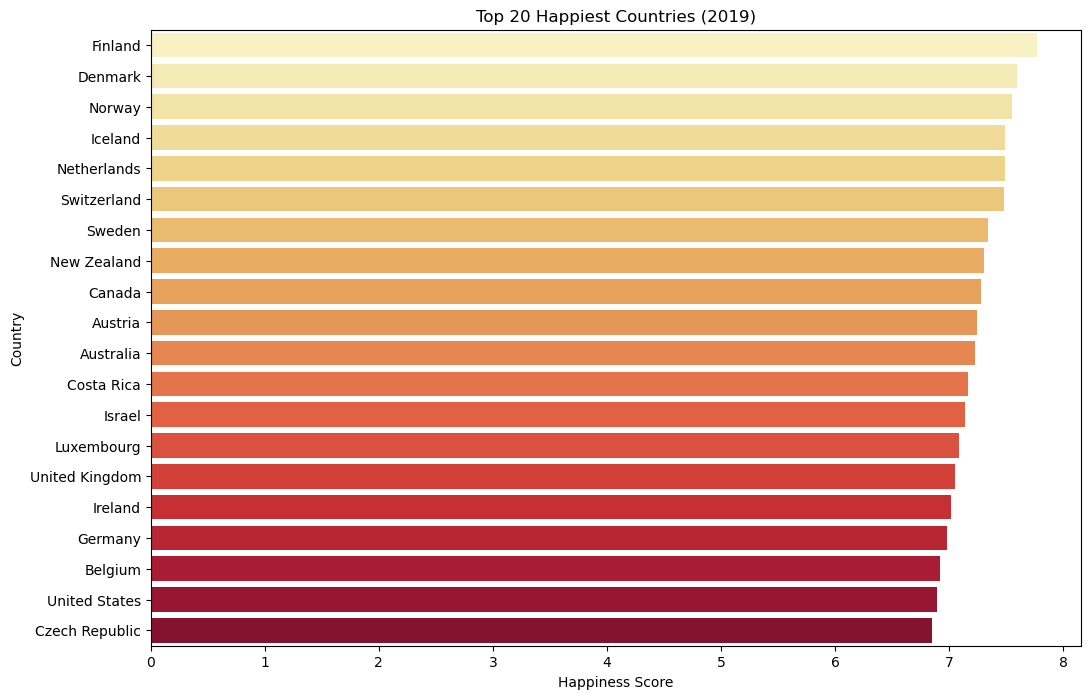

In [5]:
plt.figure(figsize=(12, 8))

top20 = df.head(20)

sns.barplot(x='score', y='country', data=top20, palette='YlOrRd')

plt.title('Top 20 Happiest Countries (2019)')
plt.xlabel('Happiness Score')
plt.ylabel('Country')

plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10468\4171103840.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score', y='country', data=bottom20, palette='RdBu')


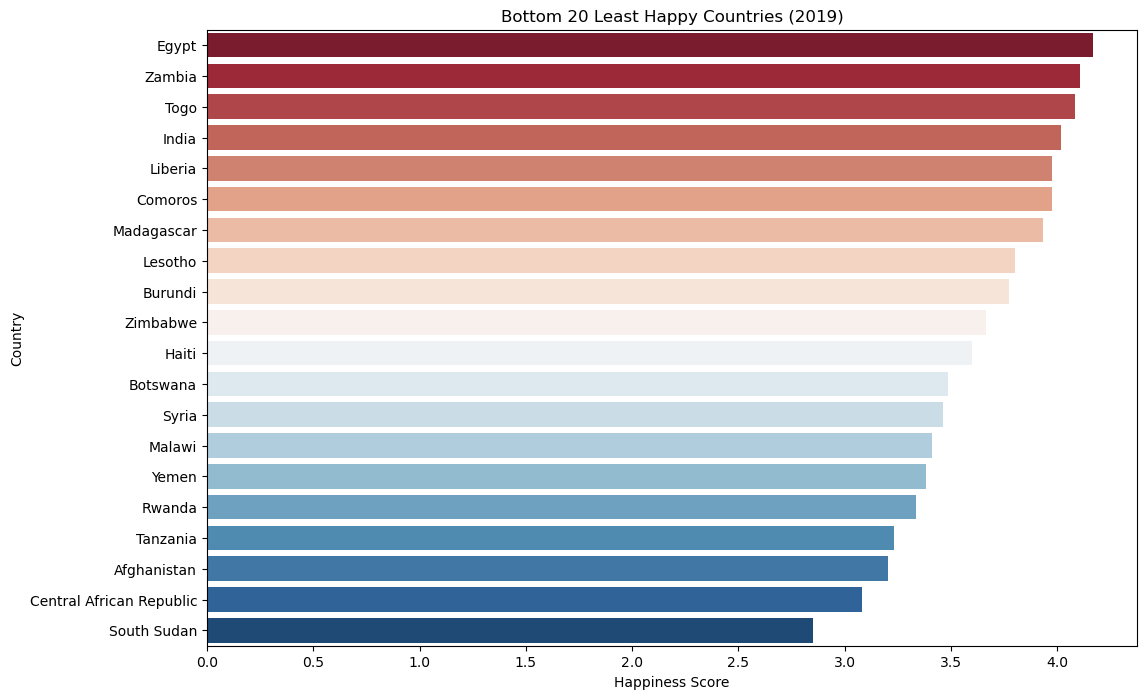

In [6]:
plt.figure(figsize=(12, 8))

bottom20 = df.tail(20)

sns.barplot(x='score', y='country', data=bottom20, palette='RdBu')

plt.title('Bottom 20 Least Happy Countries (2019)')
plt.xlabel('Happiness Score')
plt.ylabel('Country')

plt.show()

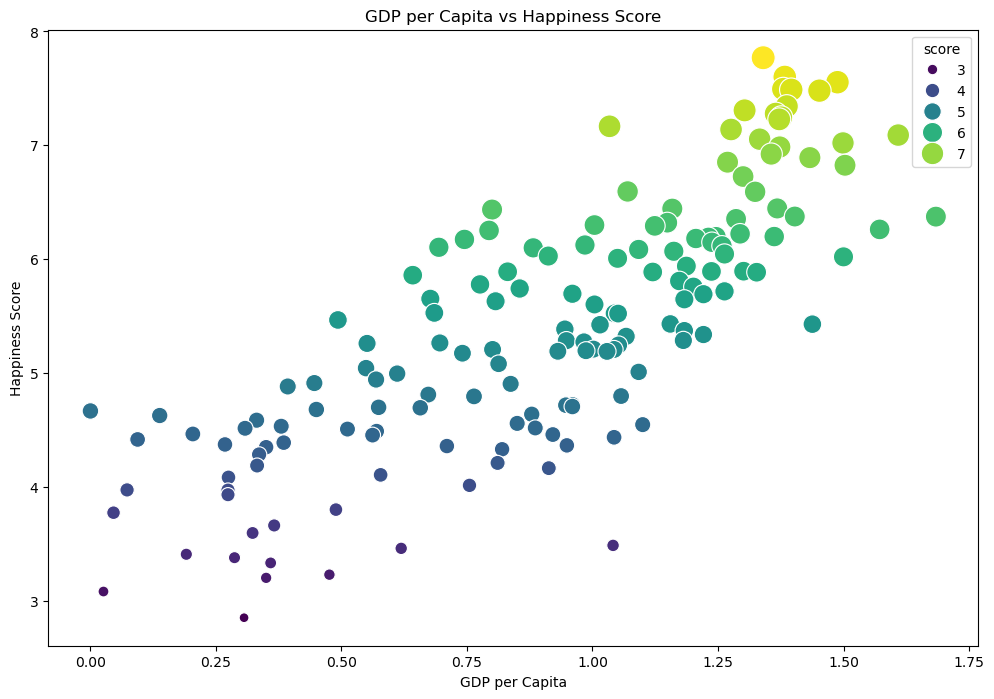

In [7]:
plt.figure(figsize=(12, 8))

sns.scatterplot(x='gdp', y='score', data=df, hue='score', palette='viridis', 
                size='score', sizes=(50, 300))

plt.title('GDP per Capita vs Happiness Score')
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")

plt.show()

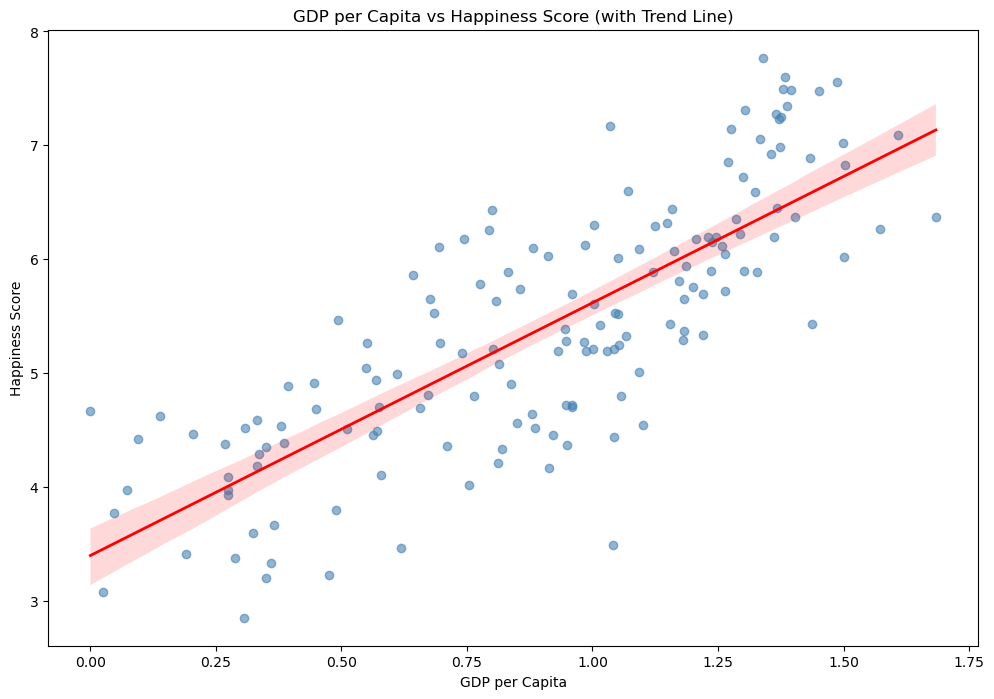

In [8]:
plt.figure(figsize=(12, 8))

sns.regplot(x='gdp', y='score', data=df, 
            scatter_kws={'alpha': 0.6, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 2})

plt.title('GDP per Capita vs Happiness Score (with Trend Line)')
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')

plt.show()


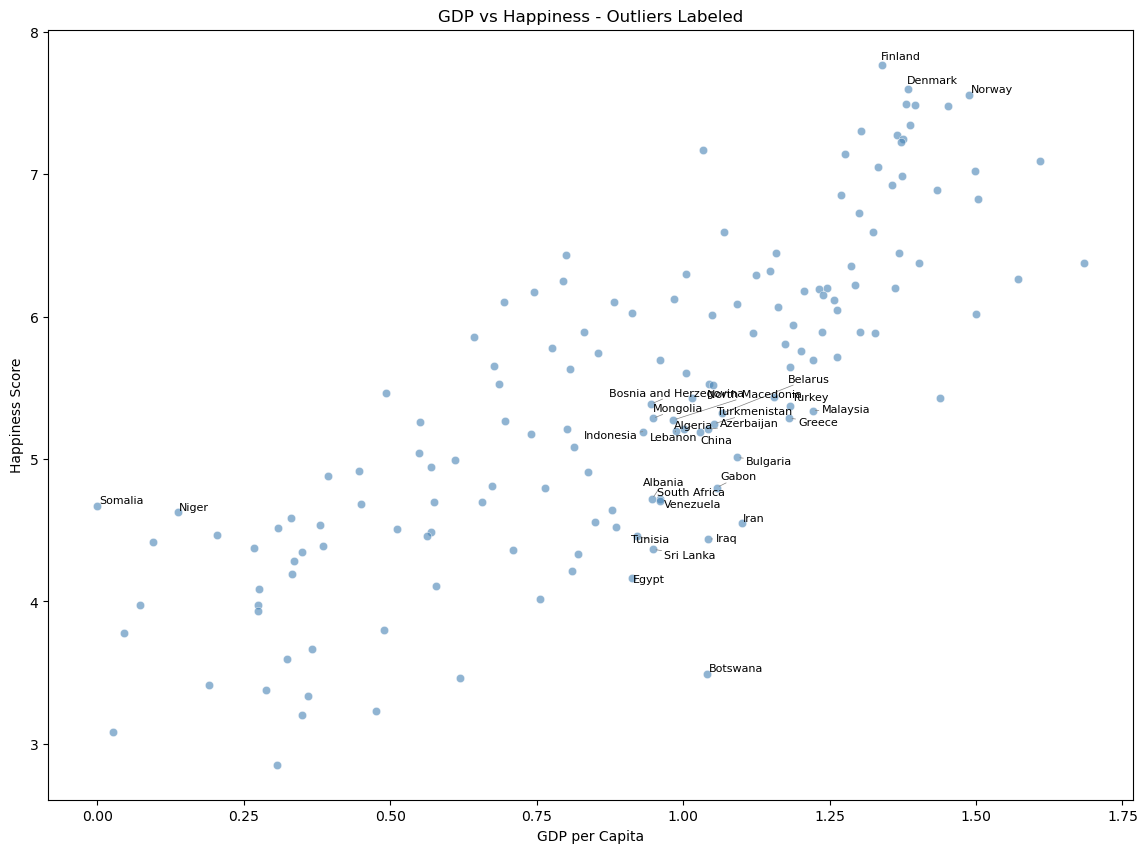

In [10]:
from adjustText import adjust_text

plt.figure(figsize=(14, 10))

sns.scatterplot(x='gdp', y='score', data=df, color='steelblue', alpha=0.6)

avg_score = df['score'].mean()
avg_gdp = df['gdp'].mean()

# Collect labels first
texts = []
for i, row in df.iterrows():
    if (row['gdp'] > avg_gdp and row['score'] < avg_score) or \
       (row['gdp'] < 0.3 and row['score'] > 4.5) or \
       (row['score'] > 7.5):
        texts.append(plt.text(row['gdp'], row['score'], row['country'], fontsize=8))

# Automatically adjust label positions to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.title('GDP vs Happiness - Outliers Labeled')
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')

plt.show()